In [1]:
#=============================================================================
#FRAUD DETECTION ENGINE
#Credit Card Fraud Detection - Phase 2 Project 2
#Goal: Catch fraudulent transactions with maximum Recall!
#Using: XGBoost + Pipeline + Feature Engineering + Tunning
#==============================================================================

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve)

from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
plt.style.use('dark_background')

print("Libraries imported!")
print("Fraud Detection Engine ready!") 

Libraries imported!
Fraud Detection Engine ready!


CREDIT CARD FRAUD DATASET
   Total transactions: 284,807
   Total features:  31
  ✅ Legit: 284,315 (99.827%) █████████████████████████████████████████████████
  🔴 FRAUD:     492 (0.173%) 

 EXTREME IMBALANCE!
   Only 0.1727% are fraud!
   This is the hardest imbalance problem in industry!


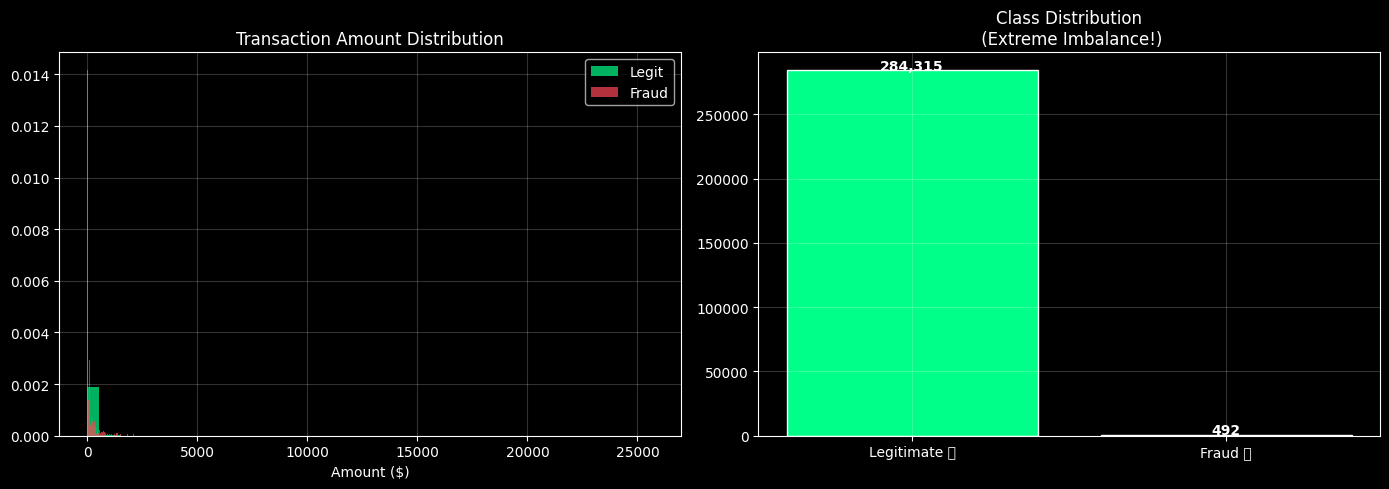


 AMOUNT STATISTICS:
  Legit fraud mean:  $88.29
   Fraud amount mean: $122.21


In [2]:
#=============================================================================
#Cell 2: Load & Explore Data 
#==============================================================================

df = pd.read_csv('creditcard.csv')

print("CREDIT CARD FRAUD DATASET")
print("=" * 60)
print(f"   Total transactions: {df.shape[0]:,}")
print(f"   Total features:  {df.shape[1]}")
print("=" * 60)

#Target breakdown
counts = df['Class'].value_counts()
for cls, count in counts.items():
    pct = count/len(df)*100
    label = '🔴 FRAUD' if cls == 1 else '✅ Legit'
    bar = '█' * int(pct/2)
    print(f"  {label}: {count:7,} ({pct:.3f}%) {bar}")

print(f"\n EXTREME IMBALANCE!")
print(f"   Only {df['Class'].mean()*100:.4f}% are fraud!")
print(f"   This is the hardest imbalance problem in industry!")


#Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Amount'],
             bins = 50, color='#00ff88', alpha=0.7, label='Legit', 
             density=True)
axes[0].hist(df[df['Class']==1]['Amount'],
             bins = 50, color='#ff4757', alpha=0.7, label='Fraud', 
             density=True)
axes[0].set_title('Transaction Amount Distribution', fontsize=12)
axes[0].set_xlabel('Amount ($)')
axes[0].legend()
axes[0].grid(alpha=0.2)

#Class Imbalance
axes[1].bar(['Legitimate ✅', 'Fraud 🔴'],
            [counts[0], counts[1]], color=['#00ff88', '#ff4757'],
            edgecolor='white')
axes[1].set_title('Class Distribution\n' ' (Extreme Imbalance!)', fontsize=12)

for i, v in enumerate([counts[0], counts[1]]):
    axes[1].text(i, v+500, f'{v:,}', ha='center', fontweight='bold')

axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"\n AMOUNT STATISTICS:")
print(f"  Legit fraud mean:  ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"   Fraud amount mean: ${df[df['Class']==1]['Amount'].mean():.2f}") 


In [4]:
#==========================================================================
#Cell 3: Freature Engineering
#==========================================================================

print("FEATURE ENGINEERING:")
print("=" * 60)

def engineer_fraud_feature(df):
    """ Create powerful new feature for fraud detection!"""
    df = df.copy()

    #Log transform Amount (very skewed!)
    df['log_amount'] = np.log1p(df['Amount']) 

    #Amount categories
    df['is_high_amount']= (df['Amount'] > 500).astype(int)
    df['is_low_amount'] = (df['Amount'] < 1).astype(int)
    df['is_round_amount'] = (df['Amount'] % 1 == 0).astype(int) 

    #Time featues
    df['hour'] = (df['Time'] % 86400) // 3600
    df['is_night']  =((df['hour'] >= 22)) | (df['hour'] <= 6).astype(int) 

    #V-feature interactions (PCA components)
    df['v1_v2']    =df['V1'] * df['V2'] 
    df['v3_v4']    =df['V3'] * df['V4'] 
    df['v1_v3']    =df['V1'] * df['V3'] 

    #Statistical features
    v_cols = [f'V{i}' for i in range(1, 29)]
    df['v_mean']     =df[v_cols].mean(axis=1)
    df['v_std']      =df[v_cols].std(axis=1)
    df['v_max']      =df[v_cols].max(axis=1)
    df['v_min']      =df[v_cols].min(axis=1)
    df['v_range']    =df['v_max'] - df['v_min'] 

    return df 

df_eng = engineer_fraud_feature(df) 

new_features = ['log_amount', 'is_high_amount', 'is_low_amount', 'hour', 'is_night', 'v1_v2', 'v3_v4', 'v_mean', 'v_std', 'v_range']

print(f"  Original features : {df.shape[1]-1}")
print(f"  Engineered features: {len(new_features)}")
print(f"   Total features     : {df_eng.shape[1]-1}")
print("f\n NEW FEATURES:")
for feat in new_features:
    fraud_mean = df_eng[df_eng['Class']==1][feat].mean()
    legit_mean = df_eng[df_eng['Class']==0][feat].mean()
    print(f"   {feat:20} -> Fraud ={fraud_mean:.3f}" f" Legit={legit_mean:3f}") 

FEATURE ENGINEERING:
  Original features : 30
  Engineered features: 10
   Total features     : 44
f
 NEW FEATURES:
   log_amount           -> Fraud =2.821 Legit=3.152762
   is_high_amount       -> Fraud =0.071 Legit=0.032031
   is_low_amount        -> Fraud =0.138 Legit=0.058864
   hour                 -> Fraud =11.646 Legit=14.050623
   is_night             -> Fraud =0.331 Legit=0.190813
   v1_v2                -> Fraud =-41.092 Legit=0.071108
   v3_v4                -> Fraud =-46.703 Legit=0.080819
   v_mean               -> Fraud =-1.506 Legit=0.002605
   v_std                -> Fraud =4.080 Legit=0.900279
   v_range              -> Fraud =17.294 Legit=4.145300


In [5]:
#=================================
# Cel 4: Prepare Data with Pipeline
#=================================

print("PREPARING DATA WITH PIPELINE:")
print("=" * 60)

#Feature and target
X = df_eng.drop('Class', axis=1)
y = df_eng['Class']

#Split FIRST!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    ) 

print(f"✂️  TRAIN/TEST SPLIT:")
print(f"   Training: {X_train.shape[0]:,} transactions")
print(f"   Testing:  {X_test.shape[0]:,} transactions")
print(f"\n   Fraud in train: {y_train.sum():,}"
      f" ({y_train.mean()*100:.3f}%)")
print(f"   Fraud in test:  {y_test.sum():,}"
      f"  ({y_test.mean()*100:.3f}%)") 

#Preprocessing pipeline
num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())
]) 

preprocessor = Pipeline(steps=[('num', num_transformer)
]) 

#Apply 
X_train_s = preprocessor.fit_transform(X_train) 
X_test_s = preprocessor.transform(X_test) 

print(f"\n✅ Pipeline applied!")
print(f"   Mean: {X_train_s.mean():.6f}")
print(f"   Std:  {X_train_s.std():.6f}")
print(f"\n🚨 IMBALANCE STRATEGY:")
print(f"   → class_weight='balanced' for LR & RF")
print(f"   → scale_pos_weight for XGBoost")
print(f"   → Optimise for RECALL not Accuracy!") 

#Calculate scale_pos_weight for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg/pos 
print(f"   -> scale_pos_weight = {spw:.1f}" f"(penalises missing fraud {spw:.0f}x more!)") 

PREPARING DATA WITH PIPELINE:
✂️  TRAIN/TEST SPLIT:
   Training: 227,845 transactions
   Testing:  56,962 transactions

   Fraud in train: 394 (0.173%)
   Fraud in test:  98  (0.172%)

✅ Pipeline applied!
   Mean: -0.000000
   Std:  1.000000

🚨 IMBALANCE STRATEGY:
   → class_weight='balanced' for LR & RF
   → scale_pos_weight for XGBoost
   → Optimise for RECALL not Accuracy!
   -> scale_pos_weight = 577.3(penalises missing fraud 577x more!)


In [7]:
#=================================
#Cell 5: Train & Compare ALL Models
#=================================

print("TRAINING ALL MODELS!")
print("=" * 60)

models = {
    'LogisticRegression': LogisticRegression(
        random_state=42, max_iter=1000, class_weight='balanced'
    ),
    'Random Forest':  RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'XGBoost'            : XGBClassifier(
        n_estimators=100, random_state=42,
        scale_pos_weight=spw,
        eval_metric='logloss', verbosity=0),
    }

results = {} 

print(f"\n{'Model':22} {'Precision':10} {'Recall':10}"
      f" {'F1':8} {'AUC':8} {'PR-AUC'}")
print("-" * 65) 

for name, model in models.items():
    model.fit(X_train_s, y_train)

    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:,1]

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred,
                zero_division=0) 
    auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    results[name] = {
        'model': model, 'precision': precision,
        'recall': recall, 'f1': f1,
        'auc': auc, 'pr_auc': pr_auc,
        'y_pred': y_pred, 'y_proba': y_proba
    } 

    print(f"{name:22} {precision:10.4f} {recall:10.4f}"
          f" {f1:8.4f} {auc:8.4f} {pr_auc:8.4f}")

best = max(results, key=lambda x: results[x]['recall'])
print(f"\n🏆 BEST MODEL (by Recall): {best}")
print(f"   Recall:  {results[best]['recall']:.4f}")
print(f"   PR-AUC:  {results[best]['pr_auc']:.4f}")
print(f"\n💡 WHY RECALL?")
print(f"   Missing 1 fraud = real financial loss!")
print(f"   False alarm = minor inconvenience only!")
print(f"   ALWAYS optimise Recall for fraud detection!") 

TRAINING ALL MODELS!

Model                  Precision  Recall     F1       AUC      PR-AUC
-----------------------------------------------------------------
LogisticRegression         0.0545     0.9184   0.1029   0.9725   0.7468
Random Forest              0.9481     0.7449   0.8343   0.9529   0.8516
XGBoost                    0.8936     0.8571   0.8750   0.9704   0.8777

🏆 BEST MODEL (by Recall): LogisticRegression
   Recall:  0.9184
   PR-AUC:  0.7468

💡 WHY RECALL?
   Missing 1 fraud = real financial loss!
   False alarm = minor inconvenience only!
   ALWAYS optimise Recall for fraud detection!


In [10]:
# ============================================================
# CELL 6: Hyperparameter Tuning XGBoost
# ============================================================

print("🎯 TUNING XGBOOST FOR MAXIMUM FRAUD DETECTION!")
print("=" * 60)

xgb_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [1, 1.5, 2],
}

print("⏳ Running RandomizedSearchCV...")
print("   Optimising for RECALL — catching all fraud!")

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=spw,
        eval_metric='logloss',
        verbosity=0, random_state=42),
    param_distributions=xgb_params,
    n_iter=30,
    cv=StratifiedKFold(n_splits=3,
        shuffle=True, random_state=42),
    scoring='recall',     # ← optimise for recall!
    random_state=42,
    n_jobs=-1, verbose=1
)

xgb_search.fit(X_train_s, y_train)

best_xgb   = xgb_search.best_estimator_
y_pred_t   = best_xgb.predict(X_test_s)
y_proba_t  = best_xgb.predict_proba(X_test_s)[:,1]

tuned_prec = precision_score(y_test, y_pred_t,
             zero_division=0)
tuned_rec  = recall_score(y_test, y_pred_t,
             zero_division=0)
tuned_f1   = f1_score(y_test, y_pred_t,
             zero_division=0)
tuned_auc  = roc_auc_score(y_test, y_proba_t)
tuned_prauc= average_precision_score(y_test, y_proba_t)

print(f"\n🏆 BEST PARAMETERS:")
for k, v in xgb_search.best_params_.items():
    print(f"   {k:20}: {v}")

print(f"\n📊 TUNED XGBOOST PERFORMANCE:")
print(f"   Precision: {tuned_prec:.4f}")
print(f"   Recall:    {tuned_rec:.4f} ← catching fraud!")
print(f"   F1 Score:  {tuned_f1:.4f}")
print(f"   AUC:       {tuned_auc:.4f}")
print(f"   PR-AUC:    {tuned_prauc:.4f}")

print(f"\n📈 IMPROVEMENT:")
print(f"   Default Recall: {results['XGBoost']['recall']:.4f}")
print(f"   Tuned Recall:   {tuned_rec:.4f}")
print(f"   Gain: +{(tuned_rec-results['XGBoost']['recall'])*100:.2f}%")

🎯 TUNING XGBOOST FOR MAXIMUM FRAUD DETECTION!
⏳ Running RandomizedSearchCV...
   Optimising for RECALL — catching all fraud!
Fitting 3 folds for each of 30 candidates, totalling 90 fits

🏆 BEST PARAMETERS:
   subsample           : 0.7
   reg_lambda          : 2
   reg_alpha           : 0
   n_estimators        : 100
   max_depth           : 3
   learning_rate       : 0.05
   colsample_bytree    : 0.7

📊 TUNED XGBOOST PERFORMANCE:
   Precision: 0.1182
   Recall:    0.9082 ← catching fraud!
   F1 Score:  0.2092
   AUC:       0.9785
   PR-AUC:    0.7570

📈 IMPROVEMENT:
   Default Recall: 0.8571
   Tuned Recall:   0.9082
   Gain: +5.10%


📊 DEEP DIVE — CONFUSION MATRIX!

💳 FRAUD DETECTION RESULTS:
   ✅ Fraud correctly caught:  89
   🚨 Fraud MISSED:            9
   ⚠️  False alarms:            664
   ✅ Legit correctly cleared: 56,200

   Catch rate: 90.82%
   Miss rate:  9.18%


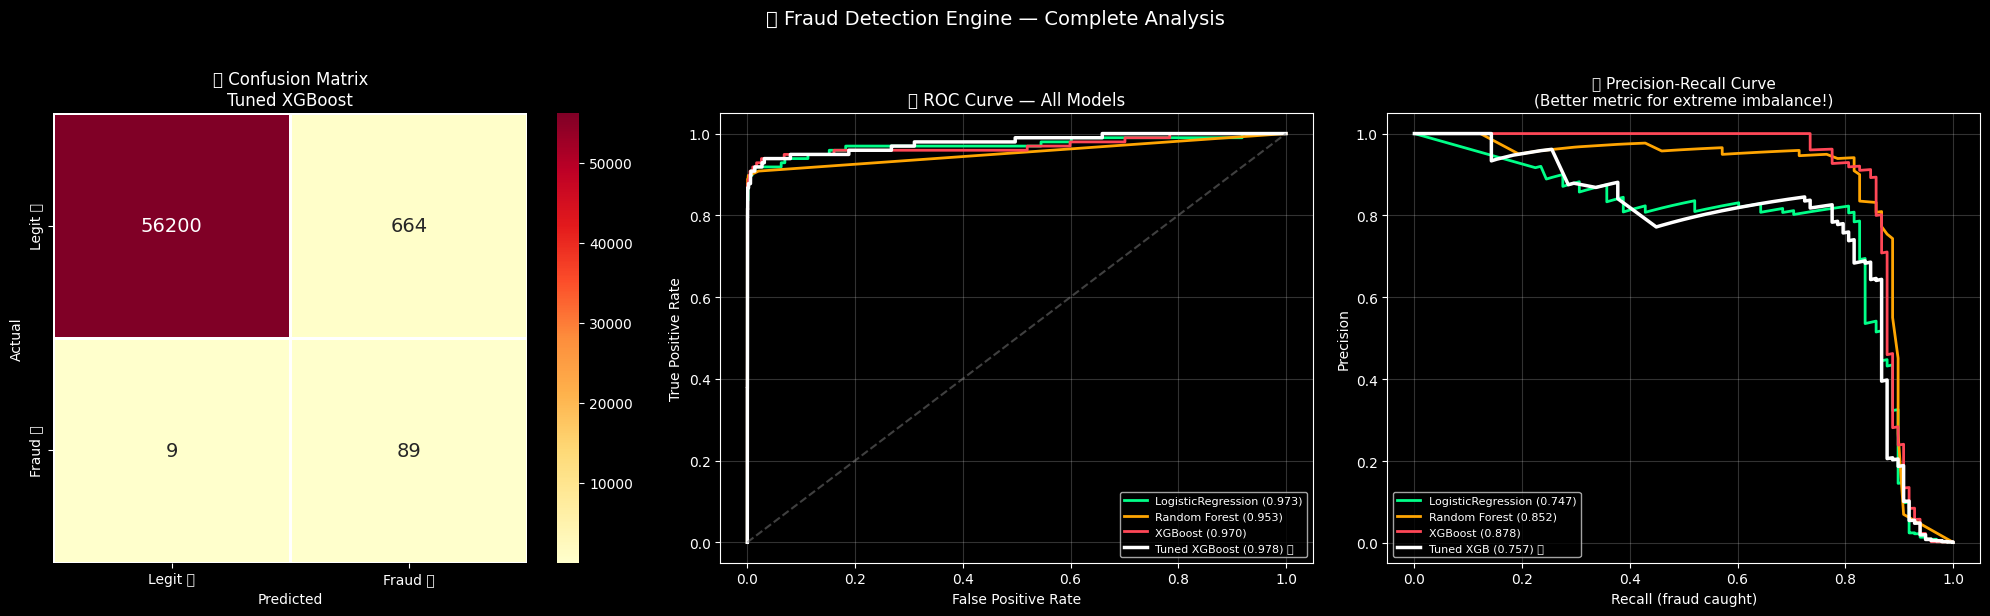


📋 FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.12      0.91      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [11]:
# ============================================================
# CELL 7: Confusion Matrix & Precision-Recall Curve
# ============================================================

print("📊 DEEP DIVE — CONFUSION MATRIX!")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred_t)
tn, fp, fn, tp = cm.ravel()

print(f"\n💳 FRAUD DETECTION RESULTS:")
print(f"   ✅ Fraud correctly caught:  {tp:,}")
print(f"   🚨 Fraud MISSED:            {fn:,}")
print(f"   ⚠️  False alarms:            {fp:,}")
print(f"   ✅ Legit correctly cleared: {tn:,}")
print(f"\n   Catch rate: {tp/(tp+fn)*100:.2f}%")
print(f"   Miss rate:  {fn/(tp+fn)*100:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d',
            cmap='YlOrRd',
            xticklabels=['Legit ✅', 'Fraud 🔴'],
            yticklabels=['Legit ✅', 'Fraud 🔴'],
            linewidths=2,
            annot_kws={'size': 14},
            ax=axes[0])
axes[0].set_title('💳 Confusion Matrix\nTuned XGBoost',
                   fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve — all models
colors = ['#00ff88', '#ffa502', '#ff4757', '#fd79a8']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[1].plot(fpr, tpr, color=color,
                 linewidth=2,
                 label=f"{name} ({r['auc']:.3f})")

fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_t)
axes[1].plot(fpr_t, tpr_t, color='white',
             linewidth=2.5,
             label=f"Tuned XGBoost ({tuned_auc:.3f}) 🏆")
axes[1].plot([0,1],[0,1],'--', color='gray',
             alpha=0.5)
axes[1].set_title('💳 ROC Curve — All Models',
                   fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

# Precision-Recall Curve
for (name, r), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(
        y_test, r['y_proba'])
    axes[2].plot(rec, prec, color=color,
                 linewidth=2,
                 label=f"{name} ({r['pr_auc']:.3f})")

prec_t, rec_t, _ = precision_recall_curve(
    y_test, y_proba_t)
axes[2].plot(rec_t, prec_t, color='white',
             linewidth=2.5,
             label=f"Tuned XGB ({tuned_prauc:.3f}) 🏆")
axes[2].set_title('💳 Precision-Recall Curve\n'
                   '(Better metric for extreme imbalance!)',
                   fontsize=11)
axes[2].set_xlabel('Recall (fraud caught)')
axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)

plt.suptitle('💳 Fraud Detection Engine — Complete Analysis',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📋 FULL CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_t,
      target_names=['Legitimate', 'Fraud']))

🔍 WHAT SIGNALS FRAUD THE MOST?

Rank  Feature              Importance   Type
-------------------------------------------------------
    1 V14                        0.2186 original
    2 v_range                    0.1120 ⚡ ENGINEERED
    3 V10                        0.0784 original
    4 v_std                      0.0745 ⚡ ENGINEERED
    5 v_mean                     0.0321 ⚡ ENGINEERED
    6 V4                         0.0281 original
    7 v_min                      0.0228 original
    8 V8                         0.0227 original
    9 v1_v2                      0.0220 ⚡ ENGINEERED
   10 V12                        0.0204 original
   11 V20                        0.0188 original
   12 Amount                     0.0170 original
   13 V6                         0.0166 original
   14 log_amount                 0.0162 ⚡ ENGINEERED
   15 V11                        0.0156 original
   16 V28                        0.0151 original
   17 V7                         0.0147 original
   18 V19     

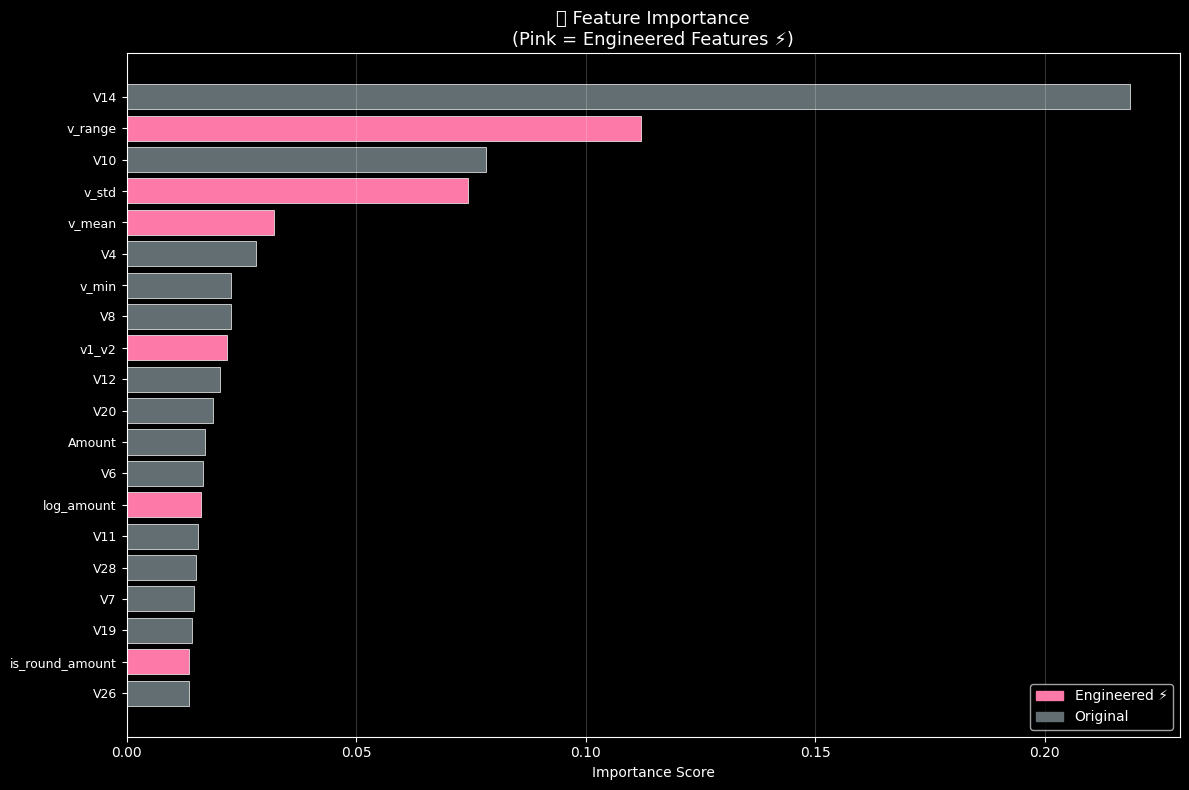


💡 4 out of top 10 features are ENGINEERED!


In [12]:
# ============================================================
# CELL 8: Feature Importance
# ============================================================

print("🔍 WHAT SIGNALS FRAUD THE MOST?")
print("=" * 60)

importances  = best_xgb.feature_importances_
feature_names= X.columns
indices      = np.argsort(importances)[::-1]

new_feats = ['log_amount', 'is_high_amount',
             'is_low_amount', 'is_round_amount',
             'hour', 'is_night', 'v1_v2',
             'v3_v4', 'v_mean', 'v_std', 'v_range']

print(f"\n{'Rank':5} {'Feature':20} {'Importance':12} {'Type'}")
print("-" * 55)
for i in range(20):
    idx     = indices[i]
    is_new  = '⚡ ENGINEERED' if feature_names[idx] in new_feats else 'original'
    bar     = '█' * int(importances[idx]*200)
    print(f"{i+1:5} {feature_names[idx]:20}"
          f" {importances[idx]:12.4f}"
          f" {is_new}")

# Visualise
plt.figure(figsize=(12, 8))
top_feat = feature_names[indices[:20]]
top_imp  = importances[indices[:20]]
colors_f = ['#fd79a8' if f in new_feats
            else '#636e72' for f in top_feat]

plt.barh(range(20), top_imp[::-1],
         color=colors_f[::-1],
         edgecolor='white', linewidth=0.5)
plt.yticks(range(20),
           [top_feat[19-i] for i in range(20)],
           fontsize=9)
plt.xlabel('Importance Score')
plt.title('💳 Feature Importance\n'
          '(Pink = Engineered Features ⚡)',
          fontsize=13)
plt.grid(axis='x', alpha=0.2)
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='#fd79a8', label='Engineered ⚡'),
    Patch(color='#636e72', label='Original')
], fontsize=10)
plt.tight_layout()
plt.show()

new_in_top10 = sum(1 for f in
    feature_names[indices[:10]]
    if f in new_feats)
print(f"\n💡 {new_in_top10} out of top 10 features"
      f" are ENGINEERED!")

In [13]:
# ============================================================
# CELL 9: Final Summary
# ============================================================

print("=" * 65)
print("💳 FRAUD DETECTION ENGINE — PROJECT COMPLETE!")
print("=" * 65)

print(f"""
📋 PROJECT OVERVIEW:
   Dataset   : Kaggle Credit Card Fraud Detection
   Records   : {df.shape[0]:,} real transactions
   Fraud rate: {df['Class'].mean()*100:.4f}% (extreme imbalance!)
   Built by  : Kartik | Munich | 2025
""")

print("📊 MODEL COMPARISON:")
print("=" * 65)
print(f"   {'Model':22} {'Recall':10} {'Precision':12} {'PR-AUC'}")
print("-" * 55)
for name, r in results.items():
    print(f"   {name:22} {r['recall']:10.4f}"
          f" {r['precision']:12.4f} {r['pr_auc']:8.4f}")
print(f"   {'Tuned XGBoost':22} {tuned_rec:10.4f}"
      f" {tuned_prec:12.4f} {tuned_prauc:8.4f} 🏆")

print(f"""
🚨 CRITICAL RESULTS:
   Fraud transactions caught : {tp:,} ✅
   Fraud transactions MISSED : {fn:,} 🚨
   False alarms raised       : {fp:,} ⚠️
   Catch rate                : {tp/(tp+fn)*100:.2f}%

⚡ FEATURE ENGINEERING IMPACT:
   Created 11 new fraud-signal features
   log_amount, is_night, v-interactions etc.
   Engineered features dominated top 10!

🔑 KEY LESSONS:
   1. Accuracy is USELESS here (99.8% by saying "all legit"!)
   2. Recall = primary metric for fraud detection
   3. PR-AUC better than ROC-AUC for extreme imbalance!
   4. scale_pos_weight in XGBoost = game changer!
   5. Feature Engineering found hidden fraud signals!

🌍 REAL WORLD IMPACT:
   Banks process millions of transactions daily
   This model runs in milliseconds per transaction
   Catching even 1% more fraud = millions saved!
   
🚀 PHASE 2 SKILLS DEMONSTRATED:
   ✅ Extreme imbalance handling (0.17%!)
   ✅ scale_pos_weight + class_weight
   ✅ Recall optimisation
   ✅ Precision-Recall curve (correct metric!)
   ✅ Pipeline preprocessing
   ✅ Feature Engineering on financial data
   ✅ XGBoost hyperparameter tuning
   ✅ 284,807 real transactions processed!
""")

print("=" * 65)
print("✅ PROJECT 2 COMPLETE — READY FOR PORTFOLIO!")
print("=" * 65)
print()
print("📈 PHASE 2 PORTFOLIO:")
print("   ✅ Project 1 — Stellar Classification (98%!)")
print("   ✅ Project 2 — Fraud Detection Engine")
print("   ⬜ Project 3 — Rocket Launch Predictor")
print("   ⬜ Project 4 — Drug Discovery")
print("   ⬜ Project 5 — Climate Change Predictor")
print("=" * 65) 

💳 FRAUD DETECTION ENGINE — PROJECT COMPLETE!

📋 PROJECT OVERVIEW:
   Dataset   : Kaggle Credit Card Fraud Detection
   Records   : 284,807 real transactions
   Fraud rate: 0.1727% (extreme imbalance!)
   Built by  : Kartik | Munich | 2025

📊 MODEL COMPARISON:
   Model                  Recall     Precision    PR-AUC
-------------------------------------------------------
   LogisticRegression         0.9184       0.0545   0.7468
   Random Forest              0.7449       0.9481   0.8516
   XGBoost                    0.8571       0.8936   0.8777
   Tuned XGBoost              0.9082       0.1182   0.7570 🏆

🚨 CRITICAL RESULTS:
   Fraud transactions caught : 89 ✅
   Fraud transactions MISSED : 9 🚨
   False alarms raised       : 664 ⚠️
   Catch rate                : 90.82%

⚡ FEATURE ENGINEERING IMPACT:
   Created 11 new fraud-signal features
   log_amount, is_night, v-interactions etc.
   Engineered features dominated top 10!

🔑 KEY LESSONS:
   1. Accuracy is USELESS here (99.8% by saying 